# Supervised machine learning: Introduction and regularization 
## Binary classification with text data

# Imports

In [1]:
## load packages 
import pandas as pd
import re
import numpy as np
import pickle
import matplotlib.pyplot as plt

## nltk imports
from nltk.tokenize import word_tokenize, wordpunct_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

## sklearn imports
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

## print mult things
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## random
import random

pd.set_option('display.max_colwidth', None)

In [2]:
## function to process text
def processtext(one_str, stop_list):
    
    ## remove stopwords
    no_stop = [tok for tok in wordpunct_tokenize(one_str)
              if tok not in stop_list]
    
    
    processed_string = " ".join([porter.stem(i.lower()) 
                        for i in no_stop if 
                        i.lower().isalpha() and len(i) >=3])
    return(processed_string)

## function to create dtm
def create_dtm(list_of_strings, metadata):
    vectorizer = CountVectorizer(lowercase = True)
    dtm_sparse = vectorizer.fit_transform(list_of_strings)
    dtm_dense_named = pd.DataFrame(dtm_sparse.todense(), columns=vectorizer.get_feature_names_out())
    dtm_dense_named_withid = pd.concat([metadata.reset_index(), dtm_dense_named], axis = 1)
    return(dtm_dense_named_withid)

# Load data

Load labeled yelp data in `public_data` and run below code

**Note**: make sure to change your path if you need to; if you're having trouble loading the `pkl`, try running on jupyter hub since it may be a python versioning issue

In [3]:
# If you have trouble loading these data (kernel dies due to memory issues), try sampling down to 5000 or 1000 rows
yelp = pd.read_pickle("../public_data/yelp_forML.pkl") #.sample(n=1000)

In [4]:
## preprocess data to create dtm
porter = PorterStemmer()
list_stopwords = stopwords.words("english")

yelp['process_text'] = [processtext(one_review, stop_list = list_stopwords) 
                        for one_review in yelp['raw_text']]

yelp_dtm = create_dtm(yelp['process_text'], yelp[['metadata_label', 'metadata_rowid',
                                                 'process_text', 'raw_text']])

# 1. Split into features, labels, and split into training/hold out

## 1.1 Split into X (features or id metadata) and y (labels)

In [5]:
# X = yelp_dtm[[col for col in yelp_dtm.columns if col not in ['metadata_label',
#                                                             'index']]].copy()
X = yelp_dtm[yelp_dtm.columns[5:]]

y = yelp_dtm[['metadata_label']]

In [6]:
## checking dimensionality
X.shape
y.shape

assert X.shape[0] == y.shape[0]
assert y.shape[1] == 1


(15000, 23438)

(15000, 1)

## 1.2 using automatic function to create train-test split

In [7]:
### using built-in function  
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                   test_size = 0.2,
                                                   random_state = 221)

In [ ]:
# This is a great function and use it as much as you can.


## 1.3 using more manual approach to create train-test split

In [27]:
# ### more manually: useful when we want more control
# ### over the ids (eg clustering or time ordering)
# ### or if we want to go back to matrix before preprocessing
# nrows_train = round(X.shape[0]*0.8)
# nrows_test = X.shape[0] - nrows_train
# random.seed(221)
# train_ids = random.sample(list(set(X['metadata_rowid'])), nrows_train)

# def my_split(X, y, 
#              train_ids, 
#              id_col):
    
#     ## get test ids
#     test_ids = set(X[id_col]).difference(train_ids)
    
#     ## split
#     X_train_man = X[X[id_col].isin(train_ids)].copy()
#     X_test_man = X[X[id_col].isin(test_ids)].copy()
#     y_train_man = y[y.index.isin(train_ids)].iloc[:, 0].to_numpy()
#     y_test_man = y[y.index.isin(test_ids)].iloc[:, 0].to_numpy()
    
#     ## return
#     return(X_train_man, X_test_man, y_train_man, y_test_man)

In [10]:
# X_train_man, X_test_man, y_train_man, y_test_man = my_split(X, y,
#                                                             train_ids, 
#                                                             id_col = 'metadata_rowid')

# 2. Estimate models with hardcoded parameters: logistic regression with L1 regularization (Lasso)

## 2.1 Estimate model using training data

NameError: name 'y_pred' is not defined

In [8]:
non_feat = ['metadata_rowid', 'raw_text', 'process_text']
logit_lasso = LogisticRegression(penalty = "l1",max_iter=100, 
             C = 0.01, solver='liblinear')
logit_lasso.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


## 2.2 Generate predictions in test data

In [10]:
y_pred = logit_lasso.predict(X_test)

y_predprob = logit_lasso.predict_proba(X_test)

In [11]:
## print the results 
y_pred[0:5]
y_predprob[0:5]


array([0, 1, 0, 1, 0])

array([[0.60287899, 0.39712101],
       [0.38636847, 0.61363153],
       [0.56241006, 0.43758994],
       [0.40041728, 0.59958272],
       [0.87820572, 0.12179428]])

## 2.3 Clean up predictions and calculate error metrics

In [12]:
## make into a dataframe
y_pred_df = pd.DataFrame({'y_pred_binary': y_pred,
                         'y_pred_continuous': [one_prob[1]
                                            for one_prob in y_predprob],
                         'y_true': y_test.metadata_label.values})

y_pred_df.sample(n = 10, random_state = 4484)


,y_pred_binary,y_pred_continuous,y_true
656,0,0.062966,0
825,1,0.771468,1
1641,0,0.380962,0
2249,1,0.507634,1
1080,0,0.492196,1
2490,0,0.318075,0
2857,0,0.328004,1
1160,1,0.785816,1
1061,0,0.455624,0
2255,1,0.708683,1


In [13]:
## precision as tp / tp+fp 
error_cond = [(y_pred_df['y_true'] == 1) & (y_pred_df['y_pred_binary'] == 1),
             (y_pred_df['y_true'] == 1) & (y_pred_df['y_pred_binary'] == 0),
              (y_pred_df['y_true'] == 0) & (y_pred_df['y_pred_binary'] == 0)]

error_codeto = ["TP", "FN", "TN"]

y_pred_df['error_cat'] = np.select(error_cond, error_codeto, default = "FP")
y_error = y_pred_df.error_cat.value_counts().reset_index().copy()
y_error.columns = ['cat', 'n']
y_error

### precision
print("Precision is:-----------")
y_error.loc[y_error.cat == "TP", 'n'].iloc[0]/(y_error.loc[y_error.cat == "TP", 'n'].iloc[0] +
                    y_error.loc[y_error.cat == "FP", 'n'].iloc[0])

### recall
print("Recall is:---------------")
y_error.loc[y_error.cat == "TP", 'n'].iloc[0]/(y_error.loc[y_error.cat == "TP", 'n'].iloc[0] +
                    y_error.loc[y_error.cat == "FN", 'n'].iloc[0])

,cat,n
0,TN,1271
1,TP,1124
2,FN,343
3,FP,262


Precision is:-----------


np.float64(0.810966810966811)

Recall is:---------------


np.float64(0.7661895023858214)

## 2.4 Interpret the model

In [14]:
## get top features
las_coef = pd.DataFrame({'coef': logit_lasso.coef_[0],
                         'feature_name': 
                        [col for col in X_train.columns if col not in non_feat]})
las_coef.sort_values(by = 'coef', ascending = False)


top_feat = las_coef.sort_values(by = 'coef', ascending = False)[0:10]
top_feat_list = top_feat.feature_name.to_list()

all_agg = [yelp_dtm.groupby(['metadata_label']).agg({one_feat: np.mean})
for one_feat in top_feat_list]
all_agg_df = pd.concat(all_agg, axis = 1)
all_agg_df

,coef,feature_name
5009,0.835614,delici
8170,0.783985,great
11106,0.602653,love
6510,0.449198,excel
526,0.438065,amaz
...,...,...
21103,-0.314480,told
20770,-0.338647,terribl
14034,-0.382531,noth
1251,-0.383946,bad


/var/folders/tw/475q0bm97v59yfl2ksmw88hr0000gn/T/ipykernel_26520/4204865.py:11: FutureWarning: The provided callable <function mean at 0x107a7dee0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  all_agg = [yelp_dtm.groupby(['metadata_label']).agg({one_feat: np.mean})


,delici,great,love,excel,amaz,best,definit,friendli,favorit,alway
metadata_label,,,,,,,,,,
0,0.026424,0.171178,0.085976,0.018819,0.022944,0.103506,0.059036,0.067672,0.027713,0.113302
1,0.162248,0.557305,0.284452,0.093621,0.104529,0.219691,0.142640,0.169014,0.116819,0.242613


<BarContainer object of 5 artists>

<BarContainer object of 5 artists>

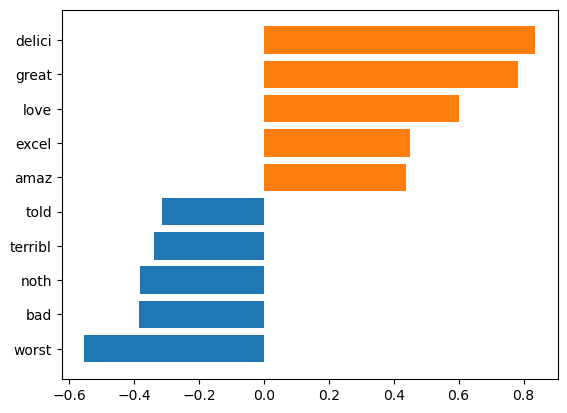

In [15]:
## get top features
las_coef = pd.DataFrame({'coef': logit_lasso.coef_[0],
                         'feature_name':
                        [col for col in X_train.columns if col not in non_feat]})

top_feat = las_coef.sort_values(by = 'coef', ascending = True)[-5:]
bot_feat = las_coef.sort_values(by = 'coef', ascending = True)[0:5]
plt.barh(bot_feat.feature_name, bot_feat.coef)
plt.barh(top_feat.feature_name, top_feat.coef)

# 3. Compare performance across hyperparameters for logistic regression

Would our logit model make more accurate predictions if we fed it different hyperpameters? Which hyperparameters would be the best? Let's find out.

1. Define a function that:
- takes in a cost parameter (*C*, the inverse of regularization strength)
- trains a logistic regression model with L1 regularization (Lasso) and otherwise has the same parameters as above
- fits the model on the training data
- makes predictions and returns them as a DataFrame

2. Use the function to get predictions for the list of *C* parameters below, then bind them into one DataFrame.

3. Finally, score the precision for each model (each iteration of *C*) and show which model scores the best.

**Hint**: To compute precision score, you can use:
```python
precision_score(
    one_df['y_true'], one_df['y_pred'],
    zero_division = 0) # silences warning
```

In [24]:
# Provided set of hyperparameters on which to train and then compare performance
c_list = np.linspace(4, 0.0001, 5)
c_list

array([4.000000e+00, 3.000025e+00, 2.000050e+00, 1.000075e+00,
       1.000000e-04])

In [21]:
#
def fit_logit_lasso(C_param, X_train, X_test, y_train, y_test):
    model = LogisticRegression(penalty="l1", max_iter=100, C=C_param, solver='liblinear')
    model.fit(X_train, y_train.values.ravel())  # flatten to 1D array
    
    y_pred = model.predict(X_test)
    
    pred_df = pd.DataFrame({
        'y_pred': y_pred,
        'y_true': y_test.metadata_label.values,
        'C': C_param
    })
    return pred_df

# Then run the loop again
all_preds = [fit_logit_lasso(c, X_train, X_test, y_train, y_test) for c in c_list]
all_preds_df = pd.concat(all_preds, ignore_index=True)

In [ ]:
def one_las(C):
    one_lasso = LogisticRegression..........

In [22]:
# your code here to evaluate precision of each model
results = []
for c_val, group in all_preds_df.groupby('C'):
    prec = precision_score(group['y_true'], group['y_pred'], zero_division=0)
    results.append({'C': c_val, 'precision': prec})

results_df = pd.DataFrame(results).sort_values('precision', ascending=False)
print(results_df)
print("\nBest C:", results_df.iloc[0]['C'])

          C  precision
1  1.000075   0.877524
2  2.000050   0.875676
3  3.000025   0.870147
4  4.000000   0.862458
0  0.000100   0.000000

Best C: 1.0000750000000003


# 4. Activity 

- Read the documentation here to initialize a ridge regression (l2 penalty)- you can use the same cost parameter (C) and number of iterations as in the lasso example above: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- Fit the model on X_train_man, y_train_main 
- Generate binary and continuous predictions
- Create a function that takes in a dataframe of binary predictions and true labels and manually calculates the $F_{1}$ score:

$$F_{1} = 2 * \dfrac{precision * recall}{precision + recall} = \dfrac{TP}{TP + 0.5(FP + FN)}$$

- Apply that function to calculate the F1 score for the decision tree and lasso (from above), and ridge regression (from the activity)
- *Challenge exercise*: parametrize the model fitting with a function that takes in a classifier as an argument and returns coefficients or feature importances and certain eval metrics (eg precision, recall, and F1)

In [23]:
# your code here 
logit_ridge = LogisticRegression(penalty="l2", max_iter=100, C=0.01, solver='liblinear')
logit_ridge.fit(X_train, y_train.values.ravel())

y_pred_ridge = logit_ridge.predict(X_test)
y_predprob_ridge = logit_ridge.predict_proba(X_test)

y_pred_ridge_df = pd.DataFrame({
    'y_pred': y_pred_ridge,
    'y_true': y_test.metadata_label.values
})

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'
